In [1]:
import os
print(os.getcwd())


C:\Users\hemaa\Downloads\Project8_pdm_Predictive Maintenance of gearboxdata\Project8_pdm_Predictive Maintenance of gearboxdata\Project8_pdm_Predictive Maintenance of gearboxdata


In [2]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'BrokenTooth Data', 'Gearbox_Predictive_Maintenance.ipynb', 'Healthy Data']


In [3]:
print(os.listdir("Healthy Data"))


['h30hz0.txt', 'h30hz10.txt', 'h30hz20.txt', 'h30hz30.txt', 'h30hz40.txt', 'h30hz50.txt', 'h30hz60.txt', 'h30hz70.txt', 'h30hz80.txt', 'h30hz90.txt']


In [4]:
import pandas as pd

sample = pd.read_csv(
    "Healthy Data/h30hz0.txt",
    sep=r"\s+",
    header=None
)

sample.head()

,0,1,2,3
0,4.636710,0.516978,-3.205940,1.82241
1,1.992800,4.184660,-2.740610,2.80436
2,-3.764110,0.997335,-1.303090,1.83668
3,-4.558710,6.104330,-1.720690,1.72311
4,0.575382,0.170980,-0.497967,-1.32895


In [5]:
sample.shape

(88832, 4)

In [6]:
sample.head(10)

,0,1,2,3
0,4.636710,0.516978,-3.205940,1.822410
1,1.992800,4.184660,-2.740610,2.804360
2,-3.764110,0.997335,-1.303090,1.836680
3,-4.558710,6.104330,-1.720690,1.723110
4,0.575382,0.170980,-0.497967,-1.328950
5,1.350040,-0.079028,1.412340,-0.525148
6,1.501600,-1.361880,3.603940,-1.256170
7,2.851170,-2.997500,0.790147,2.650570
8,1.331850,-0.690489,-1.077670,6.749580
9,-3.141570,0.724550,2.298170,-1.415430


In [7]:
import os
import pandas as pd

healthy_path = "Healthy Data"

healthy_data = []

for file in os.listdir(healthy_path):
    if file.endswith(".txt"):
        df = pd.read_csv(
            os.path.join(healthy_path, file),
            sep=r"\s+",
            header=None
        )

        df["Condition"] = "Healthy"
        df["FileName"] = file

        healthy_data.append(df)

healthy_df = pd.concat(healthy_data, ignore_index=True)

healthy_df.head()

,0,1,2,3,Condition,FileName
0,4.636710,0.516978,-3.205940,1.82241,Healthy,h30hz0.txt
1,1.992800,4.184660,-2.740610,2.80436,Healthy,h30hz0.txt
2,-3.764110,0.997335,-1.303090,1.83668,Healthy,h30hz0.txt
3,-4.558710,6.104330,-1.720690,1.72311,Healthy,h30hz0.txt
4,0.575382,0.170980,-0.497967,-1.32895,Healthy,h30hz0.txt


In [8]:
healthy_df.shape

(1015808, 6)

In [9]:
broken_path = "BrokenTooth Data"

broken_data = []

for file in os.listdir(broken_path):
    if file.endswith(".txt"):
        df = pd.read_csv(
            os.path.join(broken_path, file),
            sep=r"\s+",
            header=None
        )

        df["Condition"] = "BrokenTooth"
        df["FileName"] = file

        broken_data.append(df)

broken_df = pd.concat(broken_data, ignore_index=True)

broken_df.shape

(1005311, 6)

In [10]:
gearbox_df = pd.concat([healthy_df, broken_df], ignore_index=True)

gearbox_df.shape

(2021119, 6)

In [11]:
gearbox_df["Condition"].value_counts()

Condition
Healthy        1015808
BrokenTooth    1005311
Name: count, dtype: int64

In [12]:
gearbox_df.columns = [
    "Sensor1",
    "Sensor2",
    "Sensor3",
    "Sensor4",
    "Condition",
    "FileName"
]

gearbox_df.head()

,Sensor1,Sensor2,Sensor3,Sensor4,Condition,FileName
0,4.636710,0.516978,-3.205940,1.82241,Healthy,h30hz0.txt
1,1.992800,4.184660,-2.740610,2.80436,Healthy,h30hz0.txt
2,-3.764110,0.997335,-1.303090,1.83668,Healthy,h30hz0.txt
3,-4.558710,6.104330,-1.720690,1.72311,Healthy,h30hz0.txt
4,0.575382,0.170980,-0.497967,-1.32895,Healthy,h30hz0.txt


In [13]:
gearbox_df.isnull().sum()

Sensor1      0
Sensor2      0
Sensor3      0
Sensor4      0
Condition    0
FileName     0
dtype: int64

In [14]:
gearbox_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2021119 entries, 0 to 2021118
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Sensor1    float64
 1   Sensor2    float64
 2   Sensor3    float64
 3   Sensor4    float64
 4   Condition  object 
 5   FileName   object 
dtypes: float64(4), object(2)
memory usage: 92.5+ MB


In [15]:
gearbox_df.describe()

,Sensor1,Sensor2,Sensor3,Sensor4
count,2.021119e+06,2.021119e+06,2.021119e+06,2.021119e+06
mean,1.341575e-03,2.589083e-04,4.453338e-03,6.101136e-04
std,6.157919e+00,4.408471e+00,3.963242e+00,4.466629e+00
min,-5.872160e+01,-3.294430e+01,-2.916740e+01,-3.133450e+01
25%,-3.265495e+00,-2.432110e+00,-2.116310e+00,-2.373490e+00
50%,-7.987520e-02,9.292100e-02,4.860470e-02,1.161210e-01
75%,3.135560e+00,2.582300e+00,2.196570e+00,2.483190e+00
max,5.670660e+01,3.092830e+01,2.693890e+01,3.734990e+01


In [16]:
import matplotlib.pyplot as plt

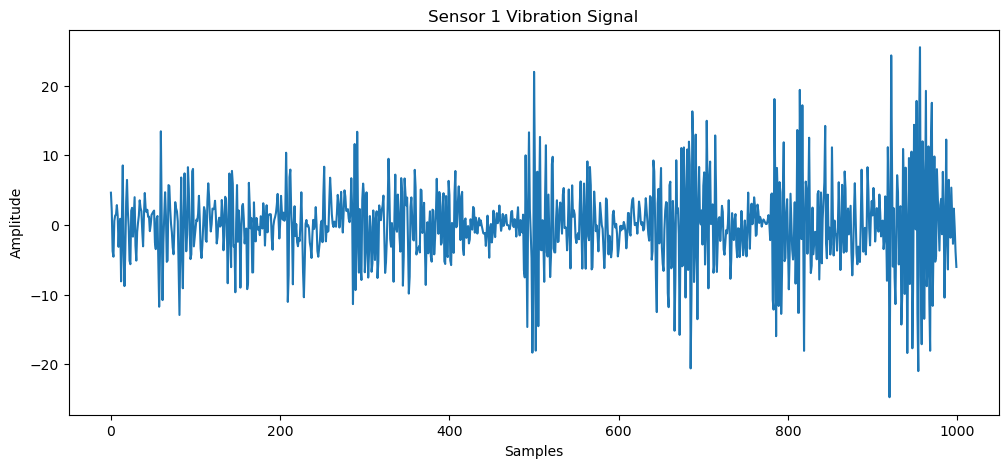

In [17]:
plt.figure(figsize=(12,5))

plt.plot(gearbox_df["Sensor1"][:1000])

plt.title("Sensor 1 Vibration Signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.show()

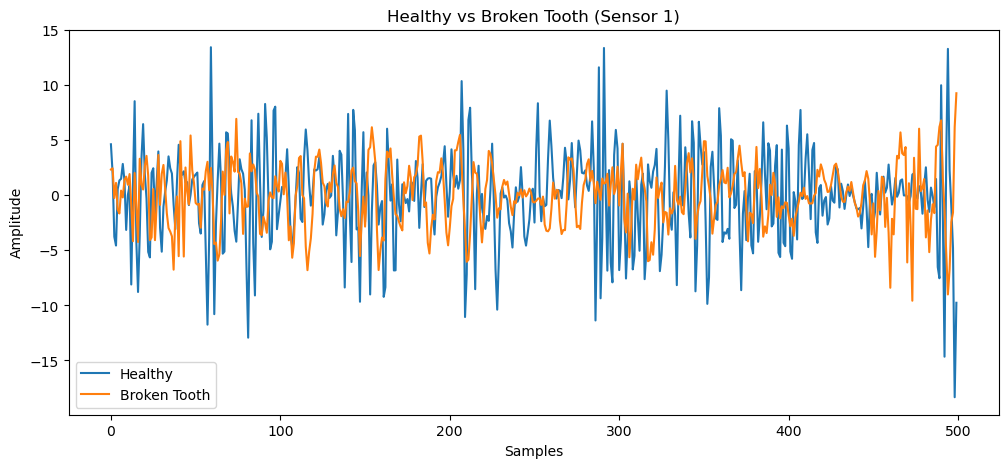

In [19]:
plt.figure(figsize=(12,5))

plt.plot(
    healthy["Sensor1"].head(500).reset_index(drop=True),
    label="Healthy"
)

plt.plot(
    broken["Sensor1"].head(500).reset_index(drop=True),
    label="Broken Tooth"
)

plt.title("Healthy vs Broken Tooth (Sensor 1)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()

plt.show()

In [20]:
gearbox_df["Label"] = gearbox_df["Condition"].map({
    "Healthy": 0,
    "BrokenTooth": 1
})

gearbox_df[["Condition", "Label"]].head()

,Condition,Label
0,Healthy,0
1,Healthy,0
2,Healthy,0
3,Healthy,0
4,Healthy,0


In [21]:
X = gearbox_df[["Sensor1", "Sensor2", "Sensor3", "Sensor4"]]

y = gearbox_df["Label"]

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples :", X_test.shape)

Training samples: (1616895, 4)
Testing samples : (404224, 4)


In [23]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [24]:
y_pred = model.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.589400926219126


In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.60      0.55      0.58    202952
           1       0.58      0.63      0.60    201272

    accuracy                           0.59    404224
   macro avg       0.59      0.59      0.59    404224
weighted avg       0.59      0.59      0.59    404224



In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[112381  90571]
 [ 75403 125869]]


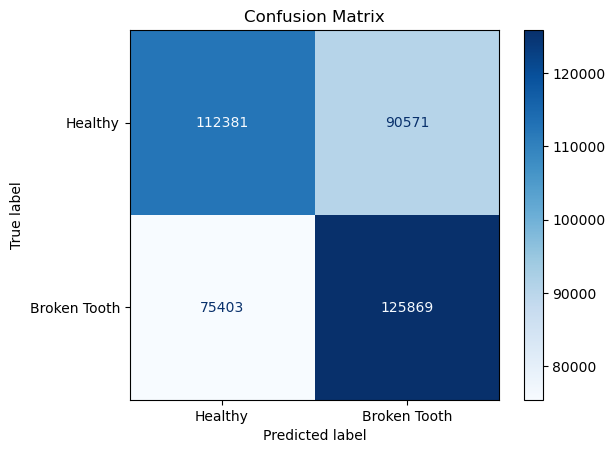

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Healthy", "Broken Tooth"])

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [29]:
gearbox_df["Mean"] = gearbox_df[["Sensor1","Sensor2","Sensor3","Sensor4"]].mean(axis=1)

gearbox_df["Std"] = gearbox_df[["Sensor1","Sensor2","Sensor3","Sensor4"]].std(axis=1)

gearbox_df["Max"] = gearbox_df[["Sensor1","Sensor2","Sensor3","Sensor4"]].max(axis=1)

gearbox_df["Min"] = gearbox_df[["Sensor1","Sensor2","Sensor3","Sensor4"]].min(axis=1)

gearbox_df["Range"] = gearbox_df["Max"] - gearbox_df["Min"]

gearbox_df.head()

,Sensor1,Sensor2,Sensor3,Sensor4,Condition,FileName,Label,Mean,Std,Max,Min,Range
0,4.636710,0.516978,-3.205940,1.82241,Healthy,h30hz0.txt,0,0.942539,3.256381,4.636710,-3.20594,7.842650
1,1.992800,4.184660,-2.740610,2.80436,Healthy,h30hz0.txt,0,1.560302,3.006650,4.184660,-2.74061,6.925270
2,-3.764110,0.997335,-1.303090,1.83668,Healthy,h30hz0.txt,0,-0.558296,2.515807,1.836680,-3.76411,5.600790
3,-4.558710,6.104330,-1.720690,1.72311,Healthy,h30hz0.txt,0,0.387010,4.596211,6.104330,-4.55871,10.663040
4,0.575382,0.170980,-0.497967,-1.32895,Healthy,h30hz0.txt,0,-0.270139,0.833162,0.575382,-1.32895,1.904332


In [30]:
X = gearbox_df[
    [
        "Sensor1",
        "Sensor2",
        "Sensor3",
        "Sensor4",
        "Mean",
        "Std",
        "Max",
        "Min",
        "Range"
    ]
]

y = gearbox_df["Label"]

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
from sklearn.ensemble import RandomForestClassifier

model2 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model2.fit(X_train, y_train)

print("Improved model trained!")

Improved model trained!


In [33]:
from sklearn.metrics import accuracy_score

pred2 = model2.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred2))

Accuracy: 0.5871967028182394


In [35]:
importance = pd.DataFrame({
    "Feature": ["Sensor1", "Sensor2", "Sensor3", "Sensor4"],
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

   Feature  Importance
0  Sensor1    0.289634
1  Sensor2    0.240801
3  Sensor4    0.238790
2  Sensor3    0.230775


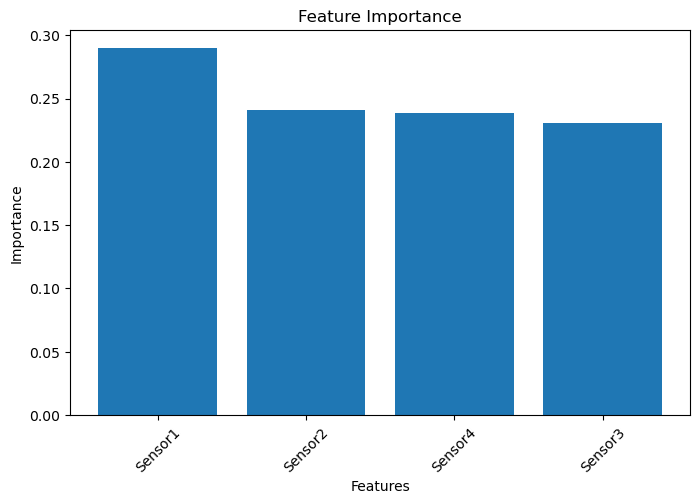

In [36]:
plt.figure(figsize=(8,5))

plt.bar(importance["Feature"], importance["Importance"])

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.show()

In [37]:
import joblib

joblib.dump(model, "gearbox_fault_model.pkl")

print("Model saved successfully!")

Model saved successfully!
